# Wilcoxon signed-rank test (paired samples)

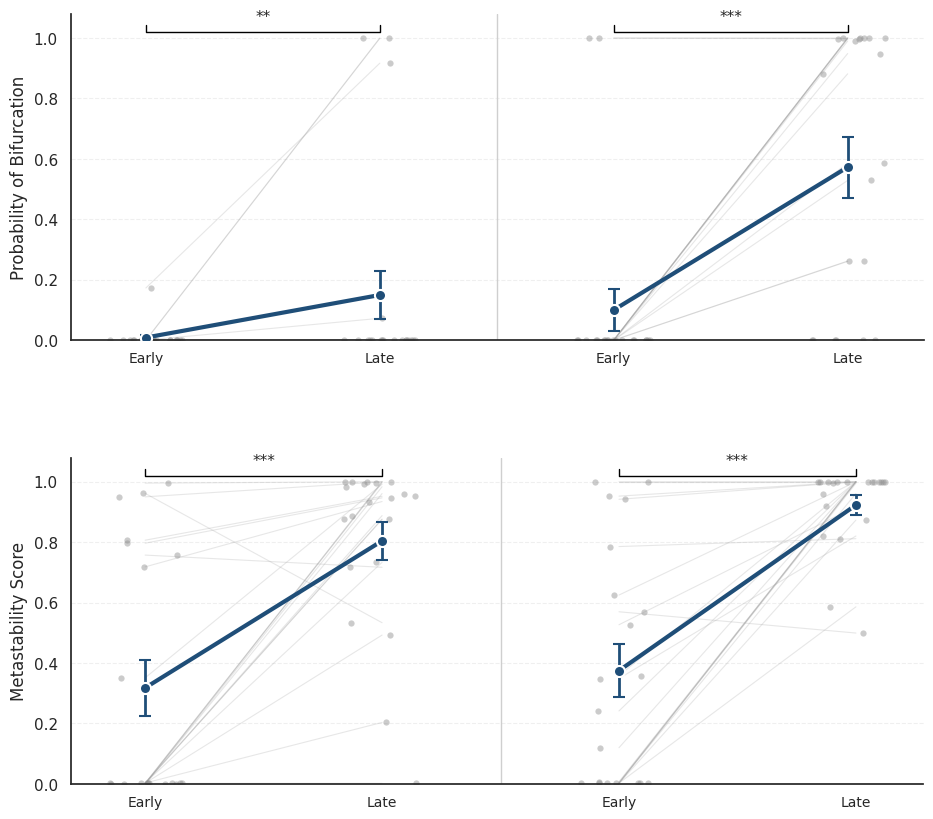

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# =======================
# Self-contained setup
# =======================
repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")

conditions = [
    ("Passive", "early"),
    ("Passive", "late"),
    ("Active", "early"),
    ("Active", "late"),
]

map_task = {"Passive": "no-report", "Active": "report"}
condition_order_plot = [
    "no-report-early",
    "no-report-late",
    "report-early",
    "report-late",
]

x_lookup = {cond: i for i, cond in enumerate(condition_order_plot)}
mean_color = "#1f4e78"  # deep navy for group-level trajectory
PANEL_GAP = 0.36  # <-- Increase/decrease this to control space between top and bottom panels

# =======================
# Load bifurcation probability
# =======================
bif_dfs = []
for task, period in conditions:
    base_path = repo_root / f"Fit_{task}_{period}_19blocks"
    csv_path = base_path / "BifurcationProbability_AllModels" / "bifurcation_probabilities.csv"

    df = pd.read_csv(csv_path, index_col=0).copy()
    if "probability_of_bifurcation" in df.columns:
        df = df.rename(columns={"probability_of_bifurcation": "bifurcation_prob"})
    if "bifurcation_prob" not in df.columns:
        raise ValueError(f"Missing bifurcation column in {csv_path}")

    df["bifurcation_prob"] = df["bifurcation_prob"].fillna(0)
    df["SubID"] = df.index.astype(str)
    df["task"] = task
    df["period"] = period
    df["task_plot"] = df["task"].map(map_task)
    df["condition_plot"] = df["task_plot"] + "-" + df["period"]
    bif_dfs.append(df)

bif_data = pd.concat(bif_dfs, ignore_index=True)

# =======================
# Load metastability score
# =======================
meta_dfs = []
for task, period in conditions:
    csv_path = repo_root / f"Fit_{task}_{period}" / "metastability_scores_bestmodel.csv"

    df = pd.read_csv(csv_path, index_col=0).copy()
    if "metastability_score" not in df.columns:
        raise ValueError(f"Missing metastability_score column in {csv_path}")

    df["SubID"] = df.index.astype(str)
    df["task"] = task
    df["period"] = period
    df["task_plot"] = df["task"].map(map_task)
    df["condition_plot"] = df["task_plot"] + "-" + df["period"]
    meta_dfs.append(df)

meta_data = pd.concat(meta_dfs, ignore_index=True)

# =======================
# Statistics helpers
# =======================
def paired_permutation_p(df, value_col, task, n_permutations=10000, seed=0):
    e = df[(df.task == task) & (df.period == "early")].set_index("SubID")
    l = df[(df.task == task) & (df.period == "late")].set_index("SubID")

    common = e.index.intersection(l.index)
    e_vals = e.loc[common, value_col]
    l_vals = l.loc[common, value_col]

    valid = ~(e_vals.isna() | l_vals.isna())
    e_vals = e_vals[valid].to_numpy()
    l_vals = l_vals[valid].to_numpy()

    if len(e_vals) < 2:
        return np.nan

    obs_diff = e_vals.mean() - l_vals.mean()
    pair_diffs = e_vals - l_vals

    rng = np.random.default_rng(seed)
    perm_diffs = np.empty(n_permutations)

    for i in range(n_permutations):
        swap_mask = rng.random(len(pair_diffs)) < 0.5
        permuted_diffs = np.where(swap_mask, -pair_diffs, pair_diffs)
        perm_diffs[i] = permuted_diffs.mean()

    return np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))


def stars_or_p(p):
    if not np.isfinite(p):
        return "n/a"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return f"p={p:.3f}"


def add_xlabels(ax):
    # Keep only Early/Late labels; major group text is intentionally removed
    ax.set_xticks([0, 1, 2, 3], ["Early", "Late", "Early", "Late"])
    ax.tick_params(axis="x", pad=2, labelsize=10)


def draw_significance_bracket(ax, x1, x2, y, text, tick=0.02, lw=1.0):
    # Thin bracket with short downward ticks at both ends
    ax.plot([x1, x1, x2, x2], [y, y - tick, y - tick, y], color="black", lw=lw, clip_on=False)
    ax.text((x1 + x2) / 2, y + tick * 0.15, text, ha="center", va="bottom", fontsize=11)


def plot_panel(ax, df, value_col, y_label):
    # Individual paired trajectories: muted gray to reduce clutter
    for task in ["Passive", "Active"]:
        early = df[(df.task == task) & (df.period == "early")]
        late = df[(df.task == task) & (df.period == "late")]

        for sub in set(early.SubID).intersection(late.SubID):
            y1 = early.loc[early.SubID == sub, value_col].values[0]
            y2 = late.loc[late.SubID == sub, value_col].values[0]
            x1 = x_lookup[f"{map_task[task]}-early"]
            x2 = x_lookup[f"{map_task[task]}-late"]
            ax.plot([x1, x2], [y1, y2], color="#a0a0a0", alpha=0.25, lw=0.8, zorder=1)

    # Individual points in matching muted tone
    sns.stripplot(
        data=df,
        x="condition_plot",
        y=value_col,
        order=condition_order_plot,
        jitter=0.16,
        size=4.5,
        alpha=0.45,
        color="#8d8d8d",
        ax=ax,
        zorder=2,
    )

    # Group means and SEM
    stats = (
        df.groupby("condition_plot")[value_col]
        .agg(["mean", "sem"])
        .reindex(condition_order_plot)
    )

    # Mean trajectory inside each task block
    ax.plot([0, 1], [stats.loc["no-report-early", "mean"], stats.loc["no-report-late", "mean"]],
            color=mean_color, lw=3.0, zorder=3)
    ax.plot([2, 3], [stats.loc["report-early", "mean"], stats.loc["report-late", "mean"]],
            color=mean_color, lw=3.0, zorder=3)

    ax.errorbar(
        x=np.arange(4),
        y=stats["mean"],
        yerr=stats["sem"],
        fmt="o",
        color=mean_color,
        markerfacecolor=mean_color,
        markeredgecolor="white",
        markeredgewidth=1.5,
        capsize=4,
        markersize=8,
        lw=2.0,
        zorder=4,
    )

    # Subtle horizontal gridlines for value reading
    ax.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.8)
    ax.set_axisbelow(True)

    # Dynamic upper bound near normalized scale while leaving headroom for brackets
    data_max = np.nanmax(df[value_col].to_numpy())
    upper = max(1.0, data_max * 1.08)
    ax.set_ylim(0, upper)

    # Significance brackets, thinner and closer to data ceiling
    p_passive = paired_permutation_p(df, value_col, "Passive")
    p_active = paired_permutation_p(df, value_col, "Active")
    tick = 0.02 * upper
    y_bracket = min(upper * 0.965, data_max + 0.04 * upper)

    draw_significance_bracket(ax, 0, 1, y_bracket, stars_or_p(p_passive), tick=tick, lw=1.0)
    draw_significance_bracket(ax, 2, 3, y_bracket, stars_or_p(p_active), tick=tick, lw=1.0)

    add_xlabels(ax)
    ax.axvline(1.5, color="#cfcfcf", lw=1.0, zorder=0)  # visual separator between task groups

    ax.set_ylabel(y_label)
    ax.set_xlabel("")
    sns.despine(ax=ax)


# =======================
# Build combined figure
# =======================
sns.set_theme(style="white")
fig, axes = plt.subplots(2, 1, figsize=(11, 10), constrained_layout=False)
fig.subplots_adjust(hspace=PANEL_GAP)

plot_panel(
    ax=axes[0],
    df=bif_data,
    value_col="bifurcation_prob",
    y_label="Probability of Bifurcation",
)

plot_panel(
    ax=axes[1],
    df=meta_data,
    value_col="metastability_score",
    y_label="Metastability Score",
)

plt.savefig(repo_root / 'Bifurcation&Metastability_AcrossConditions_PersoModels.png')
plt.show()

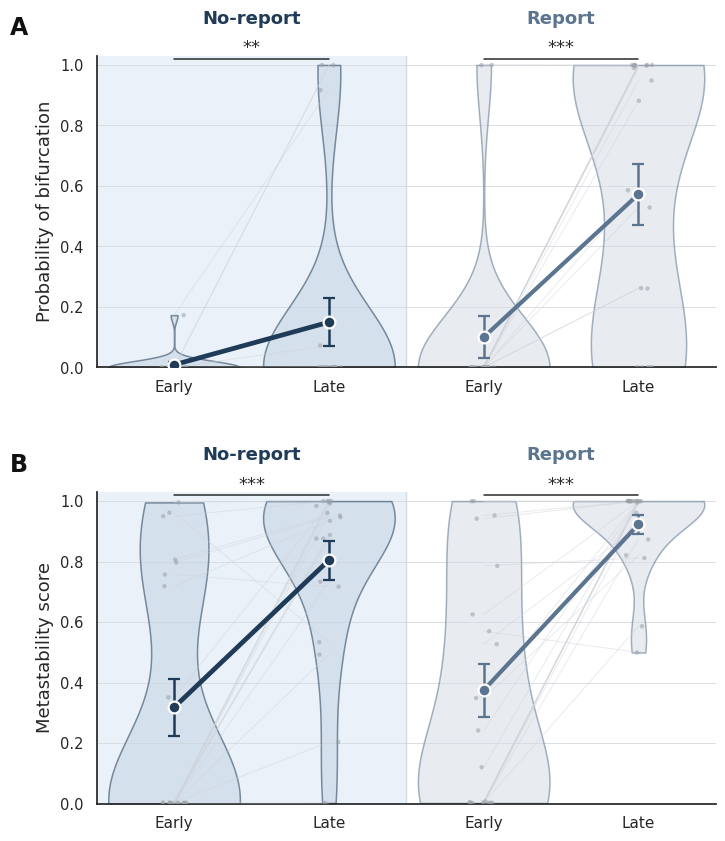

In [8]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from matplotlib.collections import PolyCollection
from pathlib import Path

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
conditions = [("Passive", "early"), ("Passive", "late"), ("Active", "early"), ("Active", "late")]
map_task = {"Passive": "no-report", "Active": "report"}
condition_order_plot = ["no-report-early", "no-report-late", "report-early", "report-late"]
x_lookup = {c: i for i, c in enumerate(condition_order_plot)}
C_MEAN = "#1f3b57"
C_MEAN_REPORT = "#5b7590"
C_VIO_NR = "#c3d3e3"
C_VIO_RP = "#d6dce3"
C_POINT = "#9aa0a8"
C_LINE = "#cfd3d9"
C_HILITE = "#eaf1f8"
C_SEP = "#d7dbe0"
PANEL_GAP = 0.40
SHOW_PAIRED_LINES = True
vio_fill = {"no-report-early": C_VIO_NR, "no-report-late": C_VIO_NR, "report-early": C_VIO_RP, "report-late": C_VIO_RP}
vio_edge = {"no-report-early": C_MEAN, "no-report-late": C_MEAN, "report-early": C_MEAN_REPORT, "report-late": C_MEAN_REPORT}

_avail = {f.name for f in font_manager.fontManager.ttflist}
_fam = next((f for f in ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"] if f in _avail), "DejaVu Sans")
mpl.rcParams.update({"font.family": _fam, "font.size": 11, "axes.linewidth": 1.0, "axes.edgecolor": "#2b2b2b", "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none"})


def paired_permutation_p(df, value_col, task, n_permutations=10000, seed=0):
    e = df[(df.task == task) & (df.period == "early")].set_index("SubID")
    l = df[(df.task == task) & (df.period == "late")].set_index("SubID")
    common = e.index.intersection(l.index)
    e_vals, l_vals = e.loc[common, value_col], l.loc[common, value_col]
    valid = ~(e_vals.isna() | l_vals.isna())
    e_vals, l_vals = e_vals[valid].to_numpy(), l_vals[valid].to_numpy()
    if len(e_vals) < 2:
        return np.nan
    obs = e_vals.mean() - l_vals.mean()
    d = e_vals - l_vals
    rng = np.random.default_rng(seed)
    perm = np.empty(n_permutations)
    for i in range(n_permutations):
        swap = rng.random(len(d)) < 0.5
        perm[i] = np.where(swap, -d, d).mean()
    return np.mean(np.abs(perm) >= np.abs(obs))


def stars_or_p(p):
    if not np.isfinite(p):
        return "n/a"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return f"p = {p:.3f}"


def _bracket(ax, x1, x2, y, text, tick, lw=1.1):
    ax.plot([x1, x2], [y, y], color="#2b2b2b", lw=lw, clip_on=False, solid_capstyle="round")
    ax.text((x1 + x2) / 2, y + tick * 0.25, text, ha="center", va="bottom", fontsize=13, color="#2b2b2b")


def _violins(ax, df, value_col):
    sns.violinplot(data=df, x="condition_plot", y=value_col, order=condition_order_plot,
                   hue="condition_plot", hue_order=condition_order_plot, legend=False,
                   palette=vio_fill, inner=None, cut=0, density_norm="width",
                   width=0.85, linewidth=1.1, saturation=1, ax=ax, zorder=2)
    bodies = [c for c in ax.collections if isinstance(c, PolyCollection)]
    for cond, body in zip(condition_order_plot, bodies):
        body.set_alpha(0.55)
        body.set_edgecolor(vio_edge[cond])
        body.set_linewidth(1.1)


def plot_panel(ax, df, value_col, y_label, panel_letter):
    ax.set_xlim(-0.55, 3.55)
    ax.axvspan(-0.55, 1.5, color=C_HILITE, lw=0, zorder=0)
    _violins(ax, df, value_col)
    if SHOW_PAIRED_LINES:
        for task in ["Passive", "Active"]:
            early = df[(df.task == task) & (df.period == "early")]
            late = df[(df.task == task) & (df.period == "late")]
            for sub in set(early.SubID).intersection(late.SubID):
                y1 = early.loc[early.SubID == sub, value_col].values[0]
                y2 = late.loc[late.SubID == sub, value_col].values[0]
                x1, x2 = x_lookup[f"{map_task[task]}-early"], x_lookup[f"{map_task[task]}-late"]
                ax.plot([x1, x2], [y1, y2], color=C_LINE, alpha=0.45, lw=0.7, zorder=3)
    sns.stripplot(data=df, x="condition_plot", y=value_col, order=condition_order_plot,
                  jitter=0.09, size=3.2, alpha=0.55, color=C_POINT,
                  edgecolor="none", ax=ax, zorder=4)
    stats = df.groupby("condition_plot")[value_col].agg(["mean", "sem"]).reindex(condition_order_plot)
    ax.plot([0, 1], [stats.loc["no-report-early", "mean"], stats.loc["no-report-late", "mean"]],
            color=C_MEAN, lw=3.4, zorder=5, solid_capstyle="round")
    ax.plot([2, 3], [stats.loc["report-early", "mean"], stats.loc["report-late", "mean"]],
            color=C_MEAN_REPORT, lw=3.0, zorder=5, solid_capstyle="round")
    for idxs, col in ([[0, 1], C_MEAN], [[2, 3], C_MEAN_REPORT]):
        ax.errorbar(x=idxs, y=stats["mean"].to_numpy()[idxs], yerr=stats["sem"].to_numpy()[idxs],
                    fmt="o", color=col, markerfacecolor=col, markeredgecolor="white",
                    markeredgewidth=1.6, capsize=4, capthick=1.4, markersize=8.5,
                    lw=0, elinewidth=1.8, zorder=6)
    ax.grid(axis="y", color=C_SEP, alpha=0.9, linestyle="-", linewidth=0.7)
    ax.set_axisbelow(True)
    upper = 1.03
    ax.set_ylim(0, upper)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.axvline(1.5, color=C_SEP, lw=1.0, zorder=1)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(["Early", "Late", "Early", "Late"])
    ax.tick_params(axis="x", pad=3, labelsize=11)
    ax.tick_params(axis="y", labelsize=10.5)
    ax.set_ylabel(y_label, fontsize=13)
    ax.set_xlabel("")
    sns.despine(ax=ax)
    ax.text(0.5, 1.09, "No-report", transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=13, fontweight="bold", color=C_MEAN)
    ax.text(2.5, 1.09, "Report", transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=13, fontweight="bold", color=C_MEAN_REPORT)
    p_passive = paired_permutation_p(df, value_col, "Passive")
    p_active = paired_permutation_p(df, value_col, "Active")
    tick = 0.022 * upper
    y_br = upper * 0.99
    _bracket(ax, 0, 1, y_br, stars_or_p(p_passive), tick)
    _bracket(ax, 2, 3, y_br, stars_or_p(p_active), tick)
    ax.text(-0.14, 1.05, panel_letter, transform=ax.transAxes, ha="left", va="bottom", fontsize=17, fontweight="bold", color="#111111")


def build_figure(bif_data, meta_data, out_stem="Bifurcation_Metastability_Violin"):
    sns.set_theme(style="white")
    fig, axes = plt.subplots(2, 1, figsize=(7.2, 8.4), constrained_layout=False)
    fig.subplots_adjust(hspace=PANEL_GAP, left=0.11, right=0.97, top=0.95, bottom=0.06)
    plot_panel(axes[0], bif_data, "bifurcation_prob", "Probability of bifurcation", "A")
    plot_panel(axes[1], meta_data, "metastability_score", "Metastability score", "B")
    fig.savefig(repo_root / f"{out_stem}.pdf", bbox_inches="tight")
    fig.savefig(repo_root / f"{out_stem}.png", dpi=600, bbox_inches="tight")
    return fig


if __name__ == "__main__":
    bif_dfs = []
    for task, period in conditions:
        csv_path = repo_root / f"Fit_{task}_{period}_19blocks" / "BifurcationProbability_AllModels" / "bifurcation_probabilities.csv"
        df = pd.read_csv(csv_path, index_col=0).copy()
        if "probability_of_bifurcation" in df.columns:
            df = df.rename(columns={"probability_of_bifurcation": "bifurcation_prob"})
        if "bifurcation_prob" not in df.columns:
            raise ValueError(f"Missing bifurcation column in {csv_path}")
        df["bifurcation_prob"] = df["bifurcation_prob"].fillna(0)
        df["SubID"] = df.index.astype(str)
        df["task"], df["period"] = task, period
        df["task_plot"] = df["task"].map(map_task)
        df["condition_plot"] = df["task_plot"] + "-" + df["period"]
        bif_dfs.append(df)
    bif_data = pd.concat(bif_dfs, ignore_index=True)
    meta_dfs = []
    for task, period in conditions:
        csv_path = repo_root / f"Fit_{task}_{period}" / "metastability_scores_bestmodel.csv"
        df = pd.read_csv(csv_path, index_col=0).copy()
        if "metastability_score" not in df.columns:
            raise ValueError(f"Missing metastability_score column in {csv_path}")
        df["SubID"] = df.index.astype(str)
        df["task"], df["period"] = task, period
        df["task_plot"] = df["task"].map(map_task)
        df["condition_plot"] = df["task_plot"] + "-" + df["period"]
        meta_dfs.append(df)
    meta_data = pd.concat(meta_dfs, ignore_index=True)
    build_figure(bif_data, meta_data)
    plt.show()


Bifurcation p (raw / corrected): {'raw': [0.0096990300969903, 0.0004999500049995, 0.00029997000299970003], 'corrected': array([0.00969903, 0.0009999 , 0.00089991])}
Metastability p (raw / corrected): {'raw': [0.00039996000399960006, 0.00019998000199980003, 0.13858614138586142], 'corrected': array([0.00079992, 0.00059994, 0.13858614])}


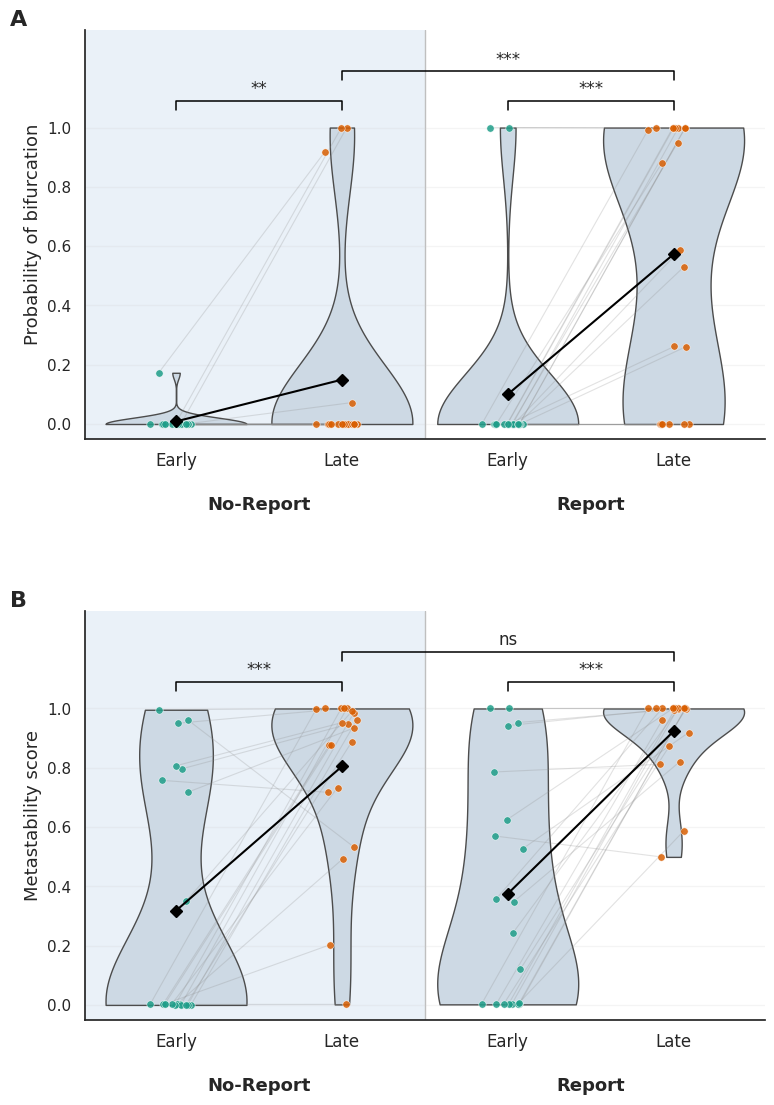

In [19]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import rankdata, wilcoxon

# ============================================================
# CONFIG
# ============================================================
repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
output_dir = repo_root
conditions = [("Passive", "early"), ("Passive", "late"), ("Active", "early"), ("Active", "late")]
map_task = {"Active": "Report", "Passive": "No-Report"}

# position of each (task, period) on the x-axis
POS = {("Passive", "early"): 0, ("Passive", "late"): 1, ("Active", "early"): 2, ("Active", "late"): 3}
order = [("Passive", "early"), ("Passive", "late"), ("Active", "early"), ("Active", "late")]

# same knobs as the model-comparison figure
comparison_statistic = "mean"   # 'mean', 'rank', or 'wilcoxon'
correction_method = "holm"      # 'holm' or 'maxT' (maxT unsupported with 'wilcoxon')

# Colors are assigned by period, not task condition.
COND_COLOR = {"early": "#1f9e89", "late": "#d95f02"}
VIOLIN_FILL = "#c9d9e8"
C_HILITE = "#eaf1f8"   # light-blue background behind the no-report block


# ============================================================
# STATS  (identical to the model-comparison script)
# ============================================================
def paired_permutation_test(x, y, n_permutations=10000, seed=42, statistic="mean"):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    diff = x - y
    if np.allclose(diff, 0.0):
        return 1.0
    if statistic == "mean":
        stat_values = diff
        observed = np.mean(stat_values)
    elif statistic == "rank":
        nonzero = ~np.isclose(diff, 0.0)
        stat_values = diff[nonzero]
        if stat_values.size == 0:
            return 1.0
        ranks = np.asarray(rankdata(np.abs(stat_values), method="average"), dtype=float)
        stat_values = np.sign(stat_values) * ranks
        observed = np.mean(stat_values)
    else:
        raise ValueError("comparison_statistic must be 'mean' or 'rank'.")
    rng = np.random.default_rng(seed)
    permuted = np.empty(n_permutations, dtype=float)
    for i in range(n_permutations):
        signs = rng.choice([-1.0, 1.0], size=stat_values.size)
        permuted[i] = np.mean(stat_values * signs)
    p = (np.sum(np.abs(permuted) >= abs(observed)) + 1.0) / (n_permutations + 1.0)
    return float(p)


def paired_wilcoxon_test(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.allclose(x - y, 0.0):
        return 1.0
    _, p = wilcoxon(x, y, zero_method="wilcox", alternative="two-sided")
    return float(p)


def holm_correction(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order_ = np.argsort(pvals)
    sorted_p = pvals[order_]
    corrected_sorted = np.empty(m, dtype=float)
    running_max = 0.0
    for i, p in enumerate(sorted_p):
        adjusted = (m - i) * p
        running_max = max(running_max, adjusted)
        corrected_sorted[i] = min(1.0, running_max)
    corrected = np.empty(m, dtype=float)
    corrected[order_] = corrected_sorted
    return corrected


def maxt_from_diffs(diff_list, statistic="mean", n_permutations=10000, seed=42):
    # family-wise max-T over a set of paired-difference arrays (sign-flip)
    stats, observed = [], []
    for diff in diff_list:
        diff = np.asarray(diff, dtype=float)
        if statistic == "mean":
            sv = diff
        else:
            nz = ~np.isclose(diff, 0.0)
            sv = diff[nz]
            if sv.size:
                sv = np.sign(sv) * np.asarray(rankdata(np.abs(sv), method="average"), dtype=float)
        stats.append(sv)
        observed.append(np.abs(np.mean(sv)) if sv.size else 0.0)
    rng = np.random.default_rng(seed)
    maxstats = np.empty(n_permutations, dtype=float)
    for i in range(n_permutations):
        perm = [np.abs(np.mean(sv * rng.choice([-1.0, 1.0], size=sv.size))) if sv.size else 0.0 for sv in stats]
        maxstats[i] = np.max(perm)
    return np.array([(np.sum(maxstats >= o) + 1.0) / (n_permutations + 1.0) for o in observed], dtype=float)


def p_to_stars(p):
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


# ============================================================
# PANEL
# ============================================================
def _aligned(cond_vals, key_x, key_y):
    a, b = cond_vals[key_x], cond_vals[key_y]
    common = a.index.intersection(b.index)
    m = ~(a.loc[common].isna() | b.loc[common].isna())
    return a.loc[common][m].to_numpy(), b.loc[common][m].to_numpy()


def plot_panel(ax, df, value_col, y_label, panel_letter):
    cond_vals = {(t, p): df[(df.task == t) & (df.period == p)].set_index("SubID")[value_col]
                 for (t, p) in conditions}

    # One deterministic horizontal offset per subject keeps paired lines aligned with points.
    rng = np.random.default_rng(42)
    subject_ids = sorted(df["SubID"].dropna().astype(str).unique())
    jitter_by_subject = dict(zip(subject_ids, rng.normal(0.0, 0.08, size=len(subject_ids))))

    # comparisons shown in this panel
    pairs = [(("Passive", "late"), ("Passive", "early"), (0, 1)),
             (("Active", "late"), ("Active", "early"), (2, 3)),
             (("Passive", "late"), ("Active", "late"), (1, 3))]
    tiers = [0, 0, 1]

    raw_p, diff_list = [], []
    for kx, ky, _ in pairs:
        x, y = _aligned(cond_vals, kx, ky)
        diff_list.append(x - y)
        if comparison_statistic == "wilcoxon":
            raw_p.append(paired_wilcoxon_test(x, y))
        else:
            raw_p.append(paired_permutation_test(x, y, statistic=comparison_statistic))
    if correction_method == "maxT":
        if comparison_statistic == "wilcoxon":
            raise ValueError("maxT is not supported with 'wilcoxon'; use 'holm'.")
        corr_p = maxt_from_diffs(diff_list, statistic=comparison_statistic)
    else:
        corr_p = holm_correction(raw_p)

    # light-blue background behind the no-report block
    ax.set_xlim(-0.55, 3.55)
    ax.axvspan(-0.55, 1.5, color=C_HILITE, lw=0, zorder=0)

    # violins (single fill); width-normalised so bounded/piled data stays legible
    violin_arrays = []
    for key in order:
        v = cond_vals[key].dropna().to_numpy().astype(float)
        v = v + np.linspace(-1e-9, 1e-9, len(v))
        violin_arrays.append(v)
    sns.violinplot(data=violin_arrays, inner=None, cut=0, density_norm="width",
                   width=0.85, bw_adjust=1.0, linewidth=1.0, ax=ax, color=VIOLIN_FILL)

    # within-condition subject trajectories use the same offsets as their points
    for task in ["Passive", "Active"]:
        e = cond_vals[(task, "early")]
        l = cond_vals[(task, "late")]
        common = e.index.intersection(l.index)
        xe, xl = POS[(task, "early")], POS[(task, "late")]
        for subject_id in common:
            offset = jitter_by_subject[str(subject_id)]
            ax.plot([xe + offset, xl + offset], [e[subject_id], l[subject_id]],
                    color="0.55", alpha=0.25, lw=0.8, zorder=1)

    # Jittered individual points use the same subject offsets as the paired lines.
    for key in order:
        values = cond_vals[key].dropna()
        xj = [POS[key] + jitter_by_subject[str(subject_id)] for subject_id in values.index]
        ax.scatter(xj, values.to_numpy(), s=28, alpha=0.85, color=COND_COLOR[key[1]],
                   edgecolors="white", linewidths=0.4, zorder=3)

    # condition means: black diamonds, connected within condition
    for task in ["Passive", "Active"]:
        xe, xl = POS[(task, "early")], POS[(task, "late")]
        me = np.nanmean(cond_vals[(task, "early")].to_numpy())
        ml = np.nanmean(cond_vals[(task, "late")].to_numpy())
        ax.plot([xe, xl], [me, ml], color="black", marker="D", markersize=6, linewidth=1.5, zorder=4)

    # significance brackets (model-figure style)
    plot_min, plot_max, span = 0.0, 1.0, 1.0
    y_base = plot_max + 0.06 * span
    y_step = 0.10 * span
    h = 0.03 * span
    for (i, j), p_corr, t in zip([pr[2] for pr in pairs], corr_p, tiers):
        y = y_base + t * y_step
        ax.plot([i, i, j, j], [y, y + h, y + h, y], color="black", lw=1.1, zorder=4)
        ax.text((i + j) / 2, y + h + 0.01 * span, p_to_stars(p_corr), ha="center", va="bottom", fontsize=12)

    y_top = y_base + (max(tiers) + 1) * y_step + h + 0.04 * span
    ax.set_ylim(plot_min - 0.05 * span, y_top)
    ax.set_xlim(-0.55, 3.55)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.axvline(1.5, color="0.75", lw=1.0, zorder=0)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(["Early", "Late", "Early", "Late"], fontsize=12)
    ax.set_ylabel(y_label, fontsize=13)
    ax.grid(axis="y", alpha=0.2)
    sns.despine(ax=ax)

    # condition group labels below the axis
    ax.text(0.5, -0.14, map_task["Passive"], transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=13, fontweight="bold", clip_on=False)
    ax.text(2.5, -0.14, map_task["Active"], transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=13, fontweight="bold", clip_on=False)
    ax.text(-0.11, 1.0, panel_letter, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=16, fontweight="bold")

    return {"raw": raw_p, "corrected": corr_p}


def build_figure(bif_data, meta_data, out_stem="Bifurcation_Metastability_ModelStyle"):
    fig, axes = plt.subplots(2, 1, figsize=(8, 11))
    fig.subplots_adjust(hspace=0.42, left=0.11, right=0.96, top=0.97, bottom=0.07)
    p1 = plot_panel(axes[0], bif_data, "bifurcation_prob", "Probability of bifurcation", "A")
    p2 = plot_panel(axes[1], meta_data, "metastability_score", "Metastability score", "B")
    print("Bifurcation p (raw / corrected):", p1)
    print("Metastability p (raw / corrected):", p2)
    fig.savefig(output_dir / f"{out_stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(output_dir / f"{out_stem}.pdf", bbox_inches="tight")
    return fig


# ============================================================
# DATA LOADING + RUN
# ============================================================
if __name__ == "__main__":
    bif_dfs = []
    for task, period in conditions:
        csv_path = repo_root / f"Fit_{task}_{period}_19blocks" / "BifurcationProbability_AllModels" / "bifurcation_probabilities.csv"
        df = pd.read_csv(csv_path, index_col=0).copy()
        if "probability_of_bifurcation" in df.columns:
            df = df.rename(columns={"probability_of_bifurcation": "bifurcation_prob"})
        df["bifurcation_prob"] = df["bifurcation_prob"].fillna(0)
        df["SubID"] = df.index.astype(str); df["task"], df["period"] = task, period
        bif_dfs.append(df)
    bif_data = pd.concat(bif_dfs, ignore_index=True)

    meta_dfs = []
    for task, period in conditions:
        csv_path = repo_root / f"Fit_{task}_{period}" / "metastability_scores_bestmodel.csv"
        df = pd.read_csv(csv_path, index_col=0).copy()
        df["SubID"] = df.index.astype(str); df["task"], df["period"] = task, period
        meta_dfs.append(df)
    meta_data = pd.concat(meta_dfs, ignore_index=True)

    build_figure(bif_data, meta_data)
    plt.show()

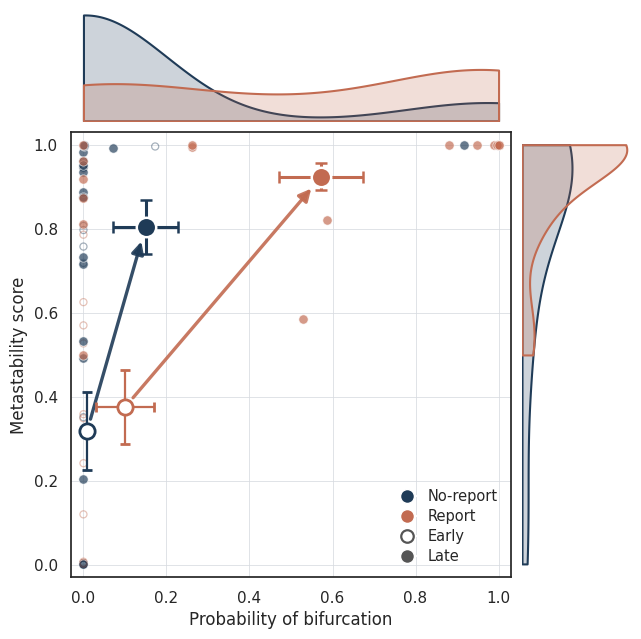

In [12]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from pathlib import Path

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
conditions = [("Passive", "early"), ("Passive", "late"), ("Active", "early"), ("Active", "late")]
map_task = {"Passive": "no-report", "Active": "report"}

C_NR = "#1f3b57"
C_RP = "#c26b51"
C_SEP = "#d7dbe0"

_avail = {f.name for f in font_manager.fontManager.ttflist}
_fam = next((f for f in ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"] if f in _avail), "DejaVu Sans")
mpl.rcParams.update({
    "font.family": _fam, "font.size": 11,
    "axes.linewidth": 1.0, "axes.edgecolor": "#2b2b2b",
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
})


def _subject_frame(bif, meta, period):
    b = bif[bif.period == period][["SubID", "task", "bifurcation_prob"]]
    m = meta[meta.period == period][["SubID", "task", "metastability_score"]]
    j = b.merge(m, on=["SubID", "task"], how="inner")
    j["cond"] = j["task"].map(map_task)
    return j


def build_jointscatter(bif, meta, out_stem="Idea2_JointScatter"):
    sns.set_theme(style="white")
    late = _subject_frame(bif, meta, "late")
    early = _subject_frame(bif, meta, "early")
    pal = {"no-report": C_NR, "report": C_RP}

    fig = plt.figure(figsize=(6.6, 6.6))
    gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                  hspace=0.04, wspace=0.04, left=0.12, right=0.97, top=0.97, bottom=0.11)
    ax = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax)

    def centroid(data, cond):
        subset = data[data.cond == cond]
        return (subset["bifurcation_prob"].mean(), subset["metastability_score"].mean(),
                subset["bifurcation_prob"].sem(), subset["metastability_score"].sem())

    for cond, color in pal.items():
        late_data = late[late.cond == cond]
        early_data = early[early.cond == cond]

        ax.scatter(early_data["bifurcation_prob"], early_data["metastability_score"],
                   s=26, alpha=0.40, facecolors="none", edgecolors=color, linewidth=0.9, zorder=2)
        ax.scatter(late_data["bifurcation_prob"], late_data["metastability_score"],
                   s=45, alpha=0.68, color=color, edgecolor="white", linewidth=0.6, zorder=3)

        early_x, early_y, early_sx, early_sy = centroid(early, cond)
        late_x, late_y, late_sx, late_sy = centroid(late, cond)
        ax.annotate("", xy=(late_x, late_y), xytext=(early_x, early_y),
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=2.4, alpha=0.9,
                                    shrinkA=9, shrinkB=11, mutation_scale=18), zorder=4)
        ax.errorbar(early_x, early_y, xerr=early_sx, yerr=early_sy, fmt="o", color=color,
                    markerfacecolor="white", markeredgecolor=color, markeredgewidth=2.0,
                    markersize=11, capsize=3.5, capthick=1.3, elinewidth=1.6, zorder=5)
        ax.errorbar(late_x, late_y, xerr=late_sx, yerr=late_sy, fmt="o", color=color,
                    markerfacecolor=color, markeredgecolor="white", markeredgewidth=1.8,
                    markersize=14, capsize=4, capthick=1.5, elinewidth=2.2, zorder=6)

        sns.kdeplot(x=late_data["bifurcation_prob"], ax=ax_top, color=color, fill=True,
                    alpha=0.22, lw=1.5, cut=0, bw_adjust=1.0)
        sns.kdeplot(y=late_data["metastability_score"], ax=ax_right, color=color, fill=True,
                    alpha=0.22, lw=1.5, cut=0, bw_adjust=1.0)

    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.set_xlabel("Probability of bifurcation", fontsize=12)
    ax.set_ylabel("Metastability score", fontsize=12)
    ax.grid(color=C_SEP, alpha=0.8, lw=0.7)
    ax.set_axisbelow(True)

    for marginal_ax in (ax_top, ax_right):
        marginal_ax.set_axis_off()

    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=C_NR, markersize=10, label="No-report"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=C_RP, markersize=10, label="Report"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="none", markeredgecolor="#555",
               markeredgewidth=1.6, markersize=9, label="Early"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#555", markersize=10, label="Late"),
    ]
    ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=10.5,
              ncol=1, handletextpad=0.4, labelspacing=0.35)
    fig.savefig(repo_root / f"{out_stem}.pdf", bbox_inches="tight")
    fig.savefig(repo_root / f"{out_stem}.png", dpi=600, bbox_inches="tight")
    return fig


# ---------- data loading ----------
def _load():
    bif_dfs = []
    for task, period in conditions:
        path = repo_root / f"Fit_{task}_{period}_19blocks" / "BifurcationProbability_AllModels" / "bifurcation_probabilities.csv"
        data = pd.read_csv(path, index_col=0).copy()
        if "probability_of_bifurcation" in data.columns:
            data = data.rename(columns={"probability_of_bifurcation": "bifurcation_prob"})
        data["bifurcation_prob"] = data["bifurcation_prob"].fillna(0)
        data["SubID"] = data.index.astype(str)
        data["task"], data["period"] = task, period
        bif_dfs.append(data)
    bif = pd.concat(bif_dfs, ignore_index=True)

    meta_dfs = []
    for task, period in conditions:
        path = repo_root / f"Fit_{task}_{period}" / "metastability_scores_bestmodel.csv"
        data = pd.read_csv(path, index_col=0).copy()
        data["SubID"] = data.index.astype(str)
        data["task"], data["period"] = task, period
        meta_dfs.append(data)
    meta = pd.concat(meta_dfs, ignore_index=True)
    return bif, meta


if __name__ == "__main__":
    bif, meta = _load()
    build_jointscatter(bif, meta)
    plt.show()